# Zomato Restaurant Data Analysis

This notebook performs exploratory data analysis (EDA) on the Zomato Bangalore Restaurants dataset to uncover insights about restaurant distribution, cuisines, ratings, pricing, and the impact of online ordering.

In [12]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style for all plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Helper Functions for Data Loading & Preprocessing

In [13]:
def load_zomato_data(filepath):
    """Load Zomato dataset with proper encoding handling."""
    encodings = ['utf-8', 'latin-1', 'iso-8859-1']
    
    for encoding in encodings:
        try:
            df = pd.read_csv(filepath, encoding=encoding)
            print(f"> Data loaded successfully with {encoding} encoding")
            print(f"  Shape: {df.shape[0]} rows, {df.shape[1]} columns")
            return df
        except UnicodeDecodeError:
            continue
    
    raise ValueError("Could not load file with any standard encoding")

def clean_data(df):
    """Clean and preprocess the Zomato dataset."""
    df_clean = df.copy()
    
    # Clean rate column (convert "4.1/5" to 4.1)
    if 'rate' in df_clean.columns:
        df_clean['rate'] = df_clean['rate'].apply(
            lambda x: float(str(x).split('/')[0].strip()) 
            if str(x).split('/')[0].strip().replace('.', '', 1).isdigit() 
            else np.nan
        )
    
    # Clean cost column (remove commas, convert to numeric)
    cost_col = None
    for col in ['approx_cost(for two people)', 'cost', 'average_cost_for_two']:
        if col in df_clean.columns:
            cost_col = col
            break
    
    if cost_col:
        df_clean[cost_col] = df_clean[cost_col].astype(str)
        df_clean[cost_col] = df_clean[cost_col].str.replace(',', '').str.extract(r'(\d+)')[0]
        df_clean[cost_col] = pd.to_numeric(df_clean[cost_col], errors='coerce')
        df_clean.rename(columns={cost_col: 'cost_for_two'}, inplace=True)
    
    # Clean votes column
    if 'votes' in df_clean.columns:
        df_clean['votes'] = pd.to_numeric(df_clean['votes'], errors='coerce')
    
    # Clean online_order and book_table columns
    for col in ['online_order', 'book_table']:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].replace({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, 'YES': 1, 'NO': 0})
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    print(f"> Data cleaned. Missing values per column:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
    
    return df_clean

## 2. Load and Prepare the Dataset

We automatically check if the real `data/zomato.csv` is present. If it is, we will analyze the real 51,000+ restaurants dataset. Otherwise, we fallback to generating synthetic sample data inside the `data/` directory.

In [14]:
def find_data_file(filename):
    """Look for a data file in the current working directory or nearby parent folders."""
    candidates = [
        os.path.join(os.getcwd(), filename),
        os.path.join(os.getcwd(), 'data', filename),
        os.path.abspath(os.path.join(os.getcwd(), '..', filename)),
        os.path.abspath(os.path.join(os.getcwd(), '..', 'data', filename)),
        os.path.abspath(os.path.join(os.getcwd(), '..', '..', filename)),
    ]
    for path in candidates:
        if os.path.exists(path) and os.path.getsize(path) > 0:
            return os.path.abspath(path)
    return os.path.abspath(os.path.join(os.getcwd(), '..', filename))

# Ensure the output folder exists for saved plots
os.makedirs('plots', exist_ok=True)

FILE_PATH = find_data_file('zomato.csv')

if os.path.exists(FILE_PATH) and os.path.getsize(FILE_PATH) > 0:
    print(f"> Found real dataset '{FILE_PATH}'. Loading...")
    df = load_zomato_data(FILE_PATH)
else:
    SAMPLE_FILE = find_data_file('zomato_sample.csv')
    print(f"> Real dataset not found or empty. Checking fallback '{SAMPLE_FILE}'...")
    if not (os.path.exists(SAMPLE_FILE) and os.path.getsize(SAMPLE_FILE) > 0):
        print(f"> Generating synthetic sample data and saving to '{SAMPLE_FILE}'...")
        np.random.seed(42)
        sample_data = {
            'name': [f'Restaurant_{i}' for i in range(500)],
            'location': np.random.choice(['Koramangala', 'BTM', 'Indiranagar', 'HSR', 'Whitefield', 
                                          'Jayanagar', 'JP Nagar', 'Marathahalli', 'Electronic City'], 500),
            'rate': np.random.uniform(2.5, 5.0, 500).round(1),
            'votes': np.random.randint(10, 5000, 500),
            'approx_cost(for two people)': np.random.choice([200, 300, 400, 500, 600, 800, 1000, 1500, 2000], 500),
            'online_order': np.random.choice(['Yes', 'No'], 500),
            'book_table': np.random.choice(['Yes', 'No'], 500),
            'cuisines': np.random.choice(['North Indian, Chinese', 'South Indian', 'Italian, Continental',
                                          'Fast Food', 'Cafe, Beverages', 'Biryani', 'Street Food'], 500)
        }
        df = pd.DataFrame(sample_data)
        os.makedirs(os.path.dirname(SAMPLE_FILE), exist_ok=True)
        df.to_csv(SAMPLE_FILE, index=False)
        print(f"> Synthetic sample data generated successfully.")
    df = load_zomato_data(SAMPLE_FILE)

print(f"> Loaded dataset from: {os.path.abspath(FILE_PATH if os.path.exists(FILE_PATH) else SAMPLE_FILE)}")

df_clean = clean_data(df)


> Real dataset not found or empty. Checking fallback 'c:\Users\Ananya\OneDrive\Documents\zomato analysis\zomato_sample.csv'...
> Generating synthetic sample data and saving to 'c:\Users\Ananya\OneDrive\Documents\zomato analysis\zomato_sample.csv'...
> Synthetic sample data generated successfully.
> Data loaded successfully with utf-8 encoding
  Shape: 500 rows, 8 columns
> Loaded dataset from: c:\Users\Ananya\OneDrive\Documents\zomato analysis\zomato_sample.csv
> Data cleaned. Missing values per column:
Series([], dtype: int64)


## 3. Basic Dataset Statistics

In [15]:
def basic_statistics(df):
    """Generate basic statistics about the dataset."""
    print("\n" + "="*60)
    print("BASIC STATISTICS")
    print("="*60)
    
    print(f"\nTotal Restaurants: {len(df)}")
    
    if 'rate' in df.columns:
        print(f"Average Rating: {df['rate'].mean():.2f}")
        print(f"Rating Range: {df['rate'].min():.1f} - {df['rate'].max():.1f}")
    
    if 'cost_for_two' in df.columns:
        print(f"Average Cost for Two: Rs. {df['cost_for_two'].mean():.0f}")
        print(f"Cost Range: Rs. {df['cost_for_two'].min():.0f} - Rs. {df['cost_for_two'].max():.0f}")
    
    if 'votes' in df.columns:
        print(f"Total Votes: {df['votes'].sum():,}")
        print(f"Average Votes per Restaurant: {df['votes'].mean():.0f}")
    
    if 'online_order' in df.columns:
        pct = df['online_order'].mean() * 100
        print(f"Online Order Available: {pct:.1f}%")
    
    if 'book_table' in df.columns:
        pct = df['book_table'].mean() * 100
        print(f"Table Booking Available: {pct:.1f}%")

basic_statistics(df_clean)


BASIC STATISTICS

Total Restaurants: 500
Average Rating: 3.77
Rating Range: 2.5 - 5.0
Average Cost for Two: Rs. 781
Cost Range: Rs. 200 - Rs. 2000
Total Votes: 1,221,222
Average Votes per Restaurant: 2442
Online Order Available: 47.2%
Table Booking Available: 49.4%


## 4. Restaurant Distribution by Location

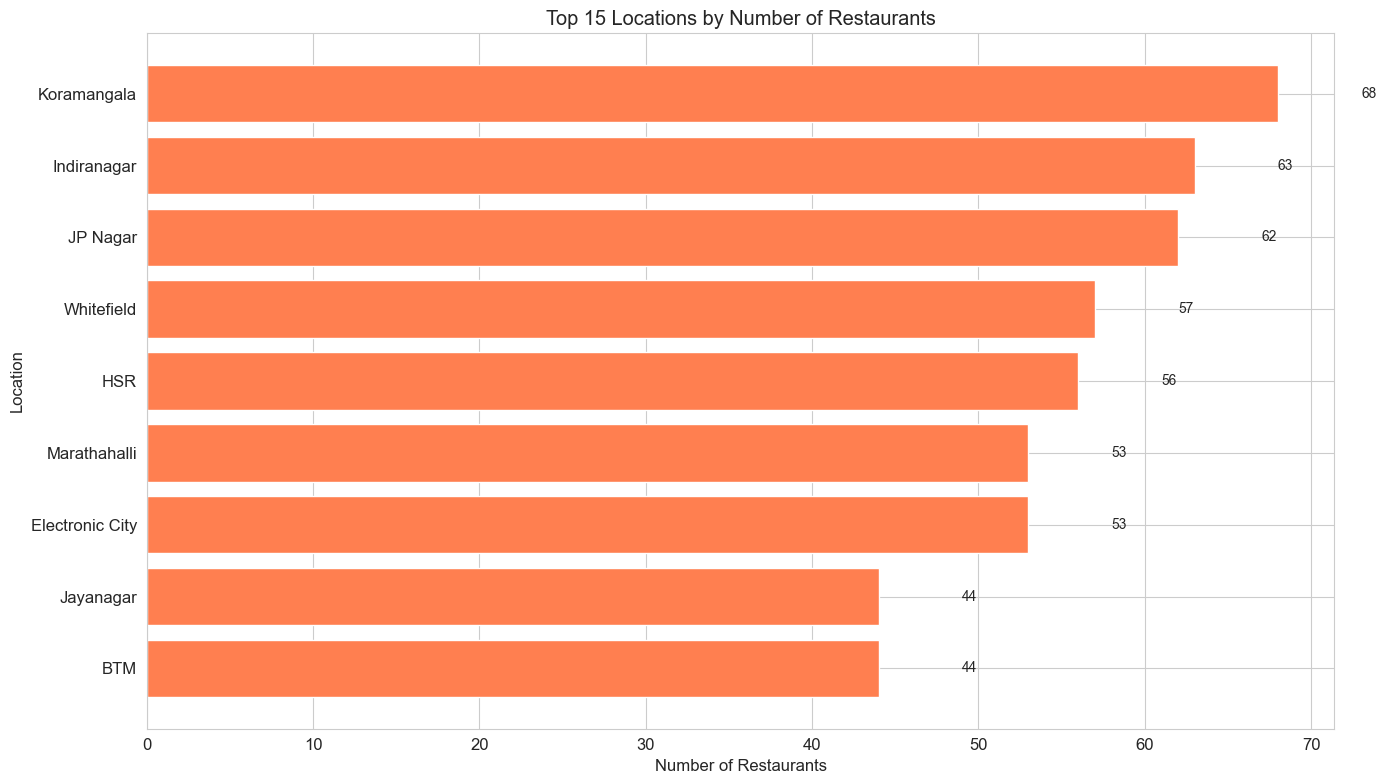

location
Koramangala        68
Indiranagar        63
JP Nagar           62
Whitefield         57
HSR                56
Marathahalli       53
Electronic City    53
Jayanagar          44
BTM                44
Name: count, dtype: int64

In [16]:
def analyze_locations(df):
    """Analyze restaurant distribution by location."""
    location_col = None
    for col in ['location', 'city', 'locality']:
        if col in df.columns:
            location_col = col
            break
    
    if not location_col:
        print("No location column found")
        return None
    
    location_counts = df[location_col].value_counts().head(15)
    
    plt.figure(figsize=(14, 8))
    bars = plt.barh(location_counts.index[::-1], location_counts.values[::-1], color='coral')
    plt.xlabel('Number of Restaurants')
    plt.ylabel('Location')
    plt.title('Top 15 Locations by Number of Restaurants')
    
    for bar, count in zip(bars, location_counts.values[::-1]):
        plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
                 str(count), va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('plots/location_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return location_counts

analyze_locations(df_clean)

## 5. Most Popular Cuisines

In [17]:
def analyze_cuisines(df):
    """Analyze most popular cuisines."""    git push origin main
    cuisine_col = None
    for col in ['cuisines', 'cuisine', 'Cuisines']:
        if col in df.columns:
            cuisine_col = col
            break
    
    if not cuisine_col:
        print("No cuisine column found")
        return None
    
    # Split multiple cuisines and count each
    all_cuisines = df[cuisine_col].dropna().str.split(',').explode()
    all_cuisines = all_cuisines.str.strip()
    cuisine_counts = all_cuisines.value_counts().head(20)
    
    plt.figure(figsize=(14, 8))
    colors = plt.cm.Spectral(np.linspace(0, 1, len(cuisine_counts)))
    bars = plt.barh(cuisine_counts.index[::-1], cuisine_counts.values[::-1], color=colors)
    plt.xlabel('Number of Restaurants')
    plt.ylabel('Cuisine Type')
    plt.title('Top 20 Most Popular Cuisines')
    plt.tight_layout()
    plt.savefig('plots/cuisine_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return cuisine_counts

analyze_cuisines(df_clean)

SyntaxError: invalid syntax (1644137131.py, line 2)

## 6. Restaurant Ratings Analysis

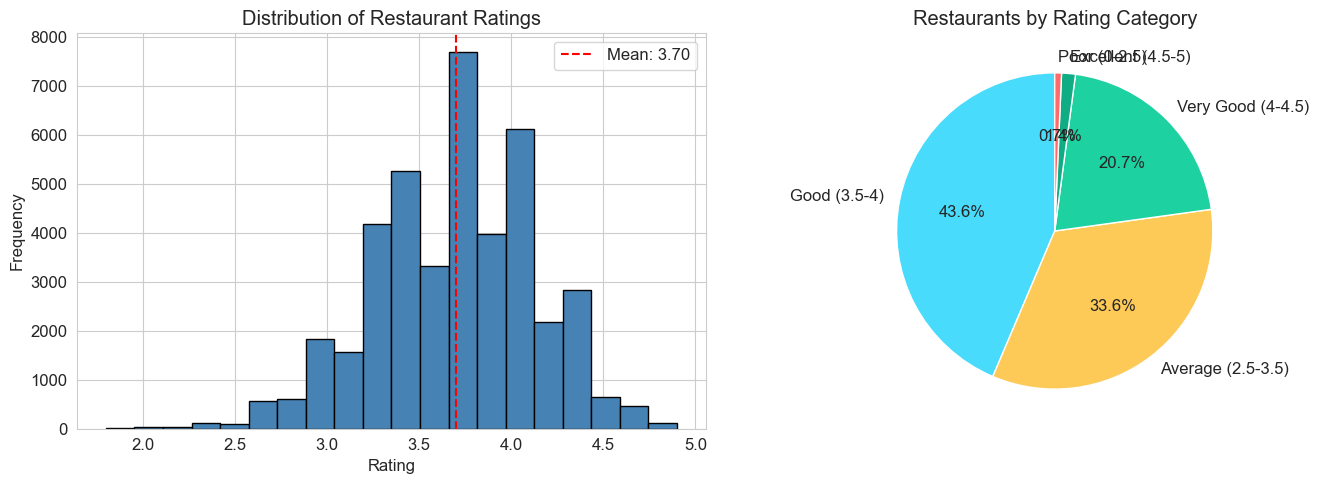

In [ ]:
def analyze_ratings(df):
    """Analyze rating distribution."""
    if 'rate' not in df.columns:
        print("No rating column found")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Rating distribution histogram
    df['rate'].dropna().hist(bins=20, ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Rating')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Restaurant Ratings')
    axes[0].axvline(df['rate'].mean(), color='red', linestyle='--', label=f'Mean: {df["rate"].mean():.2f}')
    axes[0].legend()
    
    # Rating categories
    bins = [0, 2.5, 3.5, 4.0, 4.5, 5.0]
    labels = ['Poor (0-2.5)', 'Average (2.5-3.5)', 'Good (3.5-4)', 'Very Good (4-4.5)', 'Excellent (4.5-5)']
    df['rating_category'] = pd.cut(df['rate'], bins=bins, labels=labels)
    
    category_counts = df['rating_category'].value_counts()
    category_counts = category_counts[category_counts > 0]
    color_map = dict(zip(labels, ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1', '#10ac84']))
    mapped_colors = [color_map[cat] for cat in category_counts.index]
    axes[1].pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
                colors=mapped_colors, startangle=90)
    axes[1].set_title('Restaurants by Rating Category')
    
    plt.tight_layout()
    plt.savefig('plots/rating_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

analyze_ratings(df_clean)

## 7. Cost for Two vs Restaurant Rating Correlation

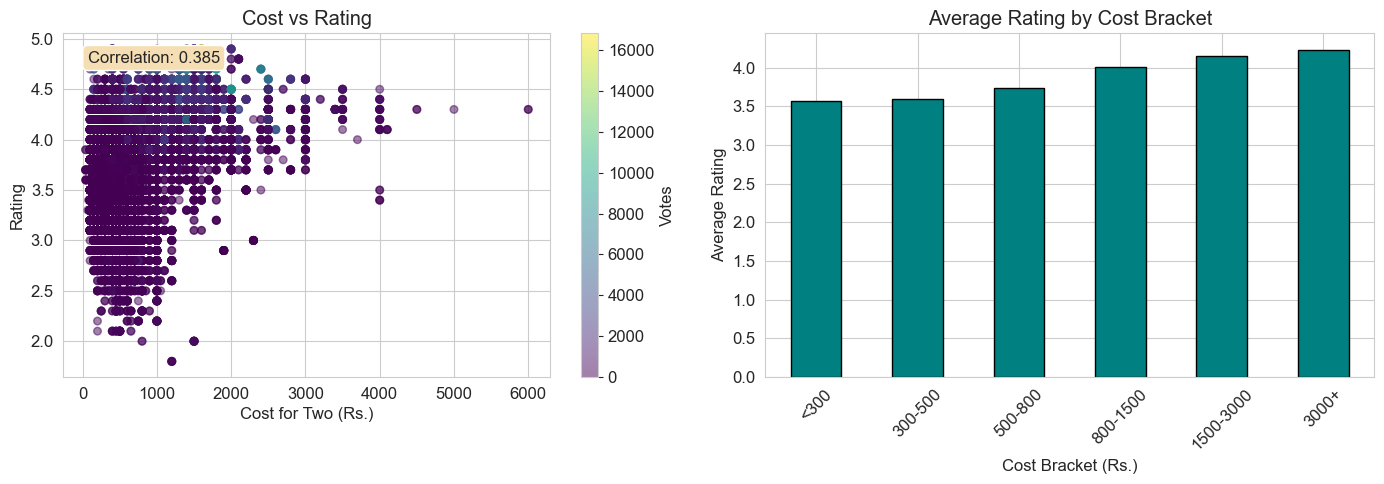

In [ ]:
def analyze_cost_vs_rating(df):
    """Analyze relationship between cost and rating."""
    if 'rate' not in df.columns or 'cost_for_two' not in df.columns:
        print("Required columns not found")
        return
    
    # Filter valid data
    valid_data = df.dropna(subset=['rate', 'cost_for_two']).copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    c_vals = valid_data['votes'].fillna(0) if 'votes' in df.columns else 'steelblue'
    scatter = axes[0].scatter(valid_data['cost_for_two'], valid_data['rate'], 
                               alpha=0.5, c=c_vals,
                               cmap='viridis', s=30)
    axes[0].set_xlabel('Cost for Two (Rs.)')
    axes[0].set_ylabel('Rating')
    axes[0].set_title('Cost vs Rating')
    if 'votes' in df.columns:
        plt.colorbar(scatter, ax=axes[0], label='Votes')
    
    # Average rating by cost bracket
    valid_data['cost_bracket'] = pd.cut(valid_data['cost_for_two'], 
                                         bins=[0, 300, 500, 800, 1500, 3000, float('inf')],
                                         labels=['<300', '300-500', '500-800', '800-1500', '1500-3000', '3000+'])
    avg_rating = valid_data.groupby('cost_bracket', observed=False)['rate'].mean()
    
    avg_rating.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
    axes[1].set_xlabel('Cost Bracket (Rs.)')
    axes[1].set_ylabel('Average Rating')
    axes[1].set_title('Average Rating by Cost Bracket')
    axes[1].tick_params(axis='x', rotation=45)
    
    # Add correlation coefficient
    corr = valid_data['cost_for_two'].corr(valid_data['rate'])
    axes[0].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[0].transAxes,
                 fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
    
    plt.tight_layout()
    plt.savefig('plots/cost_rating_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

analyze_cost_vs_rating(df_clean)

## 8. Impact of Online Ordering on Restaurant Popularity & Ratings

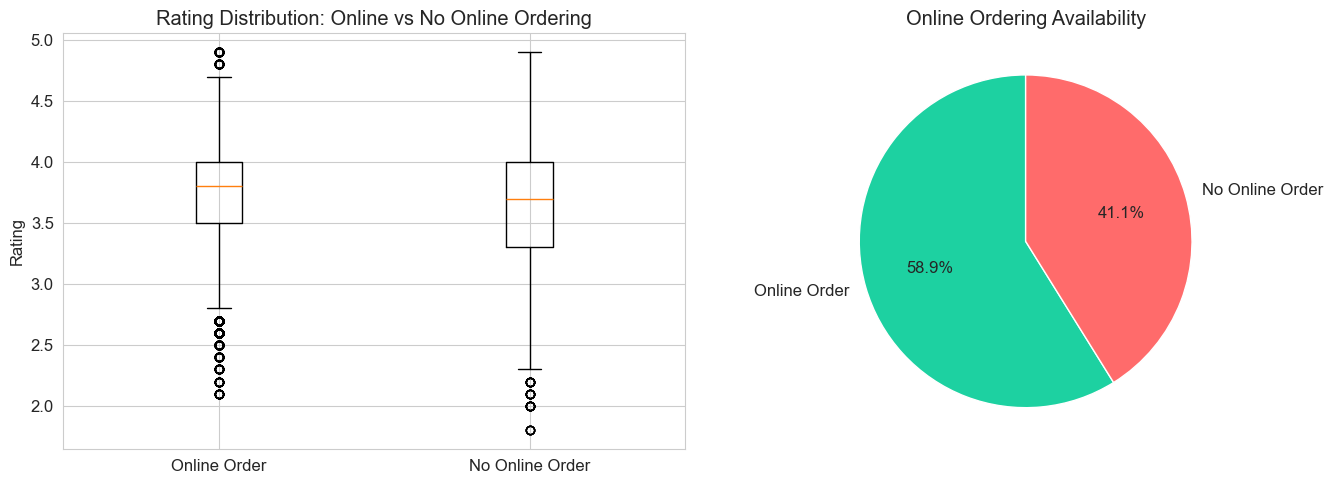


Average rating WITH online ordering: 3.72
Average rating WITHOUT online ordering: 3.66


In [ ]:
def analyze_online_ordering(df):
    """Analyze impact of online ordering on ratings."""
    if 'online_order' not in df.columns or 'rate' not in df.columns:
        print("Required columns not found")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Comparison of ratings
    online_yes = df[df['online_order'] == 1]['rate'].dropna()
    online_no = df[df['online_order'] == 0]['rate'].dropna()
    
    axes[0].boxplot([online_yes, online_no], tick_labels=['Online Order', 'No Online Order'])
    axes[0].set_ylabel('Rating')
    axes[0].set_title('Rating Distribution: Online vs No Online Ordering')
    
    # Count comparison
    online_counts = df['online_order'].value_counts()
    labels_map = {0: 'No Online Order', 1: 'Online Order'}
    colors_map = {0: '#ff6b6b', 1: '#1dd1a1'}
    pie_labels = [labels_map.get(x, 'Unknown') for x in online_counts.index]
    pie_colors = [colors_map.get(x, '#cccccc') for x in online_counts.index]
    axes[1].pie(online_counts, labels=pie_labels, autopct='%1.1f%%', colors=pie_colors, startangle=90)
    axes[1].set_title('Online Ordering Availability')
    
    plt.tight_layout()
    plt.savefig('plots/online_ordering_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nAverage rating WITH online ordering: {online_yes.mean():.2f}")
    print(f"Average rating WITHOUT online ordering: {online_no.mean():.2f}")

analyze_online_ordering(df_clean)

## 9. Feature Correlation Heatmap

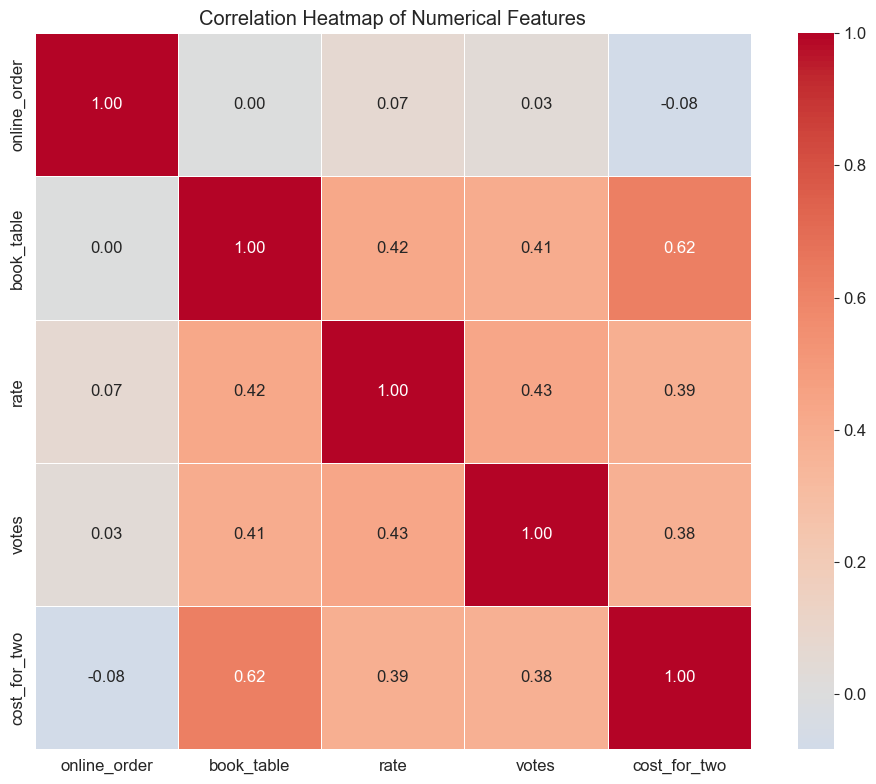

In [ ]:
def generate_heatmap(df):
    """Generate correlation heatmap for numerical columns."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if len(numeric_cols) < 2:
        print("Not enough numeric columns for correlation analysis")
        return
    
    corr_matrix = df[numeric_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', square=True, linewidths=0.5)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.tight_layout()
    plt.savefig('plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

generate_heatmap(df_clean)

## 10. Top Rated & Voted Restaurants

In [ ]:
def top_restaurants(df, n=10):
    """Find top-rated restaurants."""
    if 'rate' not in df.columns:
        print("No rating column found")
        return None
    
    # Get restaurant name column
    name_col = None
    for col in ['name', 'restaurant_name', 'Name']:
        if col in df.columns:
            name_col = col
            break
    
    if not name_col:
        name_col = df.columns[0]
    
    # Sort by rating and votes
    sort_cols = ['rate']
    if 'votes' in df.columns:
        sort_cols.append('votes')
    
    top = df.nlargest(n, sort_cols)[[name_col, 'rate'] + 
                                     (['votes'] if 'votes' in df.columns else []) +
                                     (['cost_for_two'] if 'cost_for_two' in df.columns else [])]
    
    print(f"\n{'='*60}")
    print(f"TOP {n} RESTAURANTS")
    print('='*60)
    print(top.to_string(index=False))
    
    return top

top_restaurants(df_clean)


TOP 10 RESTAURANTS
                       name  rate  votes  cost_for_two
Byg Brewski Brewing Company   4.9  16832        1600.0
Byg Brewski Brewing Company   4.9  16832        1600.0
Byg Brewski Brewing Company   4.9  16832        1600.0
Byg Brewski Brewing Company   4.9  16345        1600.0
Byg Brewski Brewing Company   4.9  16345        1600.0
Byg Brewski Brewing Company   4.9  16345        1600.0
  AB's - Absolute Barbecues   4.9   6490        1600.0
  AB's - Absolute Barbecues   4.9   6452        1600.0
  AB's - Absolute Barbecues   4.9   6404        1600.0
  AB's - Absolute Barbecues   4.9   6404        1600.0


,name,rate,votes,cost_for_two
49170,Byg Brewski Brewing Company,4.9,16832,1600.0
49627,Byg Brewski Brewing Company,4.9,16832,1600.0
50059,Byg Brewski Brewing Company,4.9,16832,1600.0
3921,Byg Brewski Brewing Company,4.9,16345,1600.0
4801,Byg Brewski Brewing Company,4.9,16345,1600.0
4944,Byg Brewski Brewing Company,4.9,16345,1600.0
37099,AB's - Absolute Barbecues,4.9,6490,1600.0
21279,AB's - Absolute Barbecues,4.9,6452,1600.0
19393,AB's - Absolute Barbecues,4.9,6404,1600.0
21770,AB's - Absolute Barbecues,4.9,6404,1600.0
